First Five Rows
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \

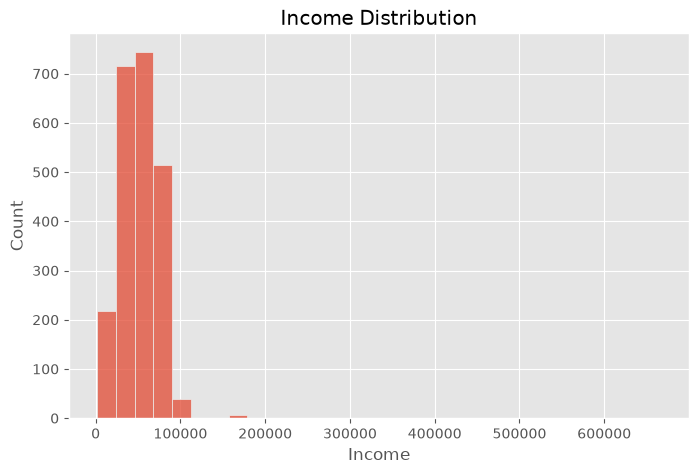

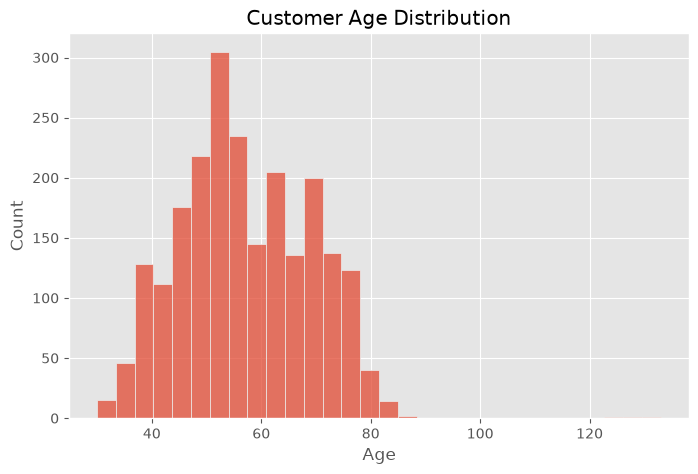

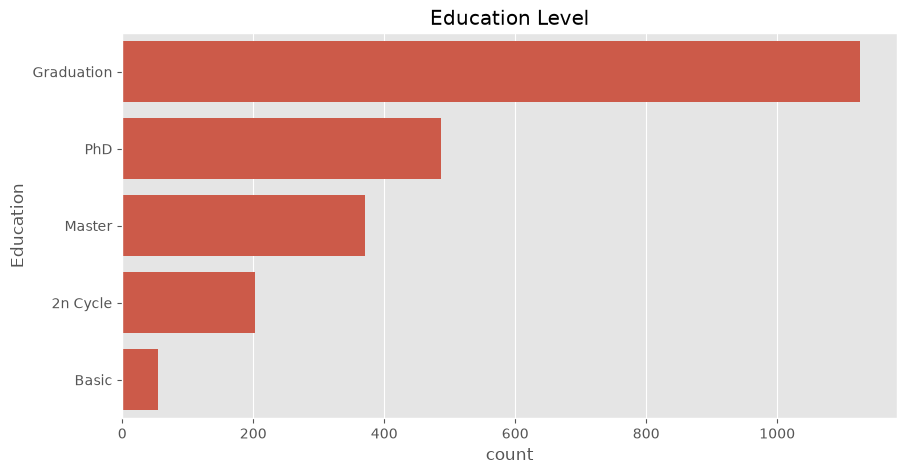

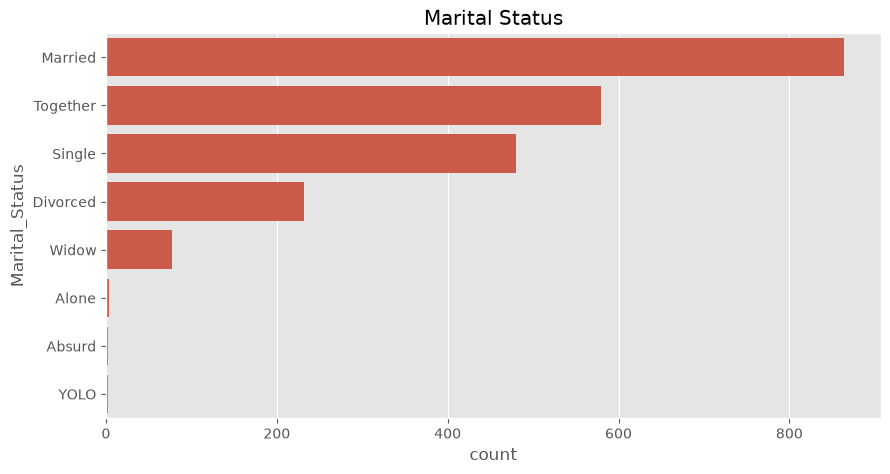

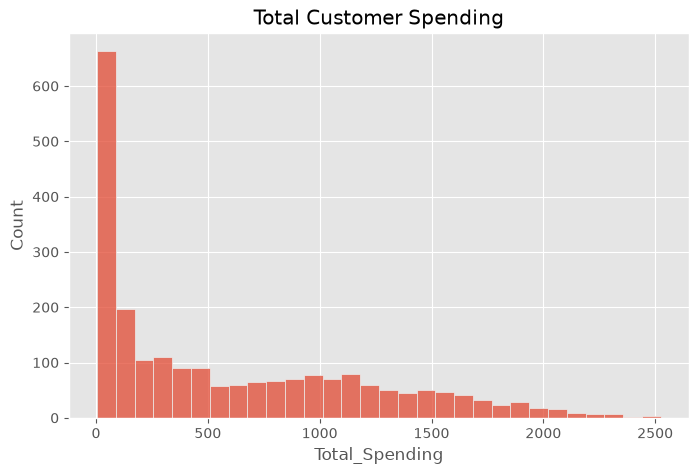

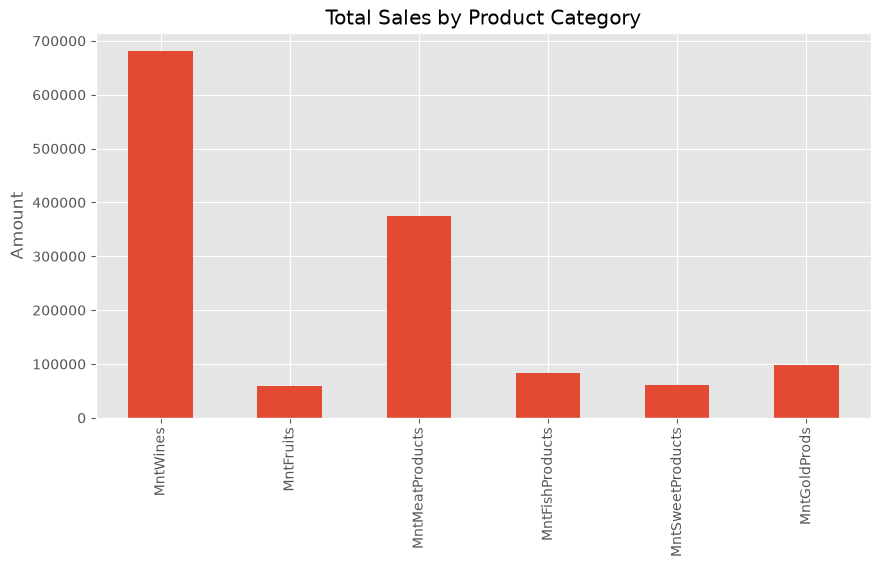

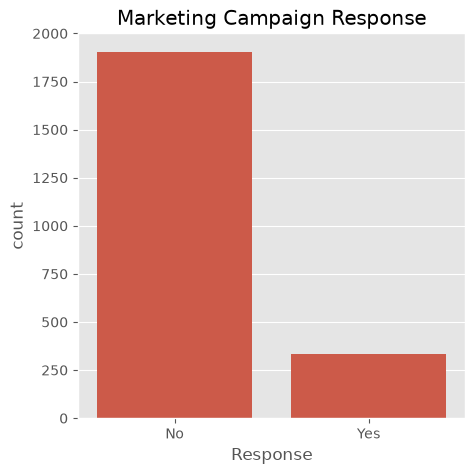

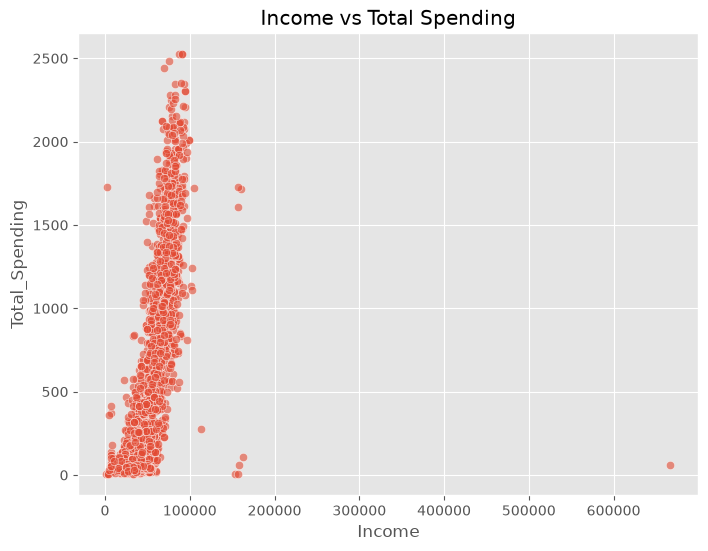

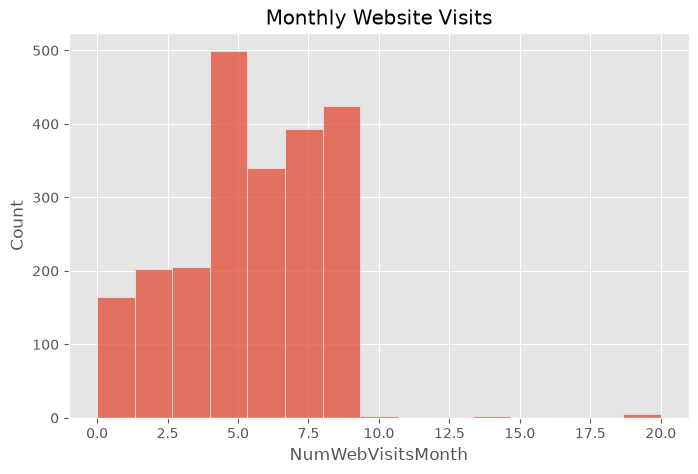

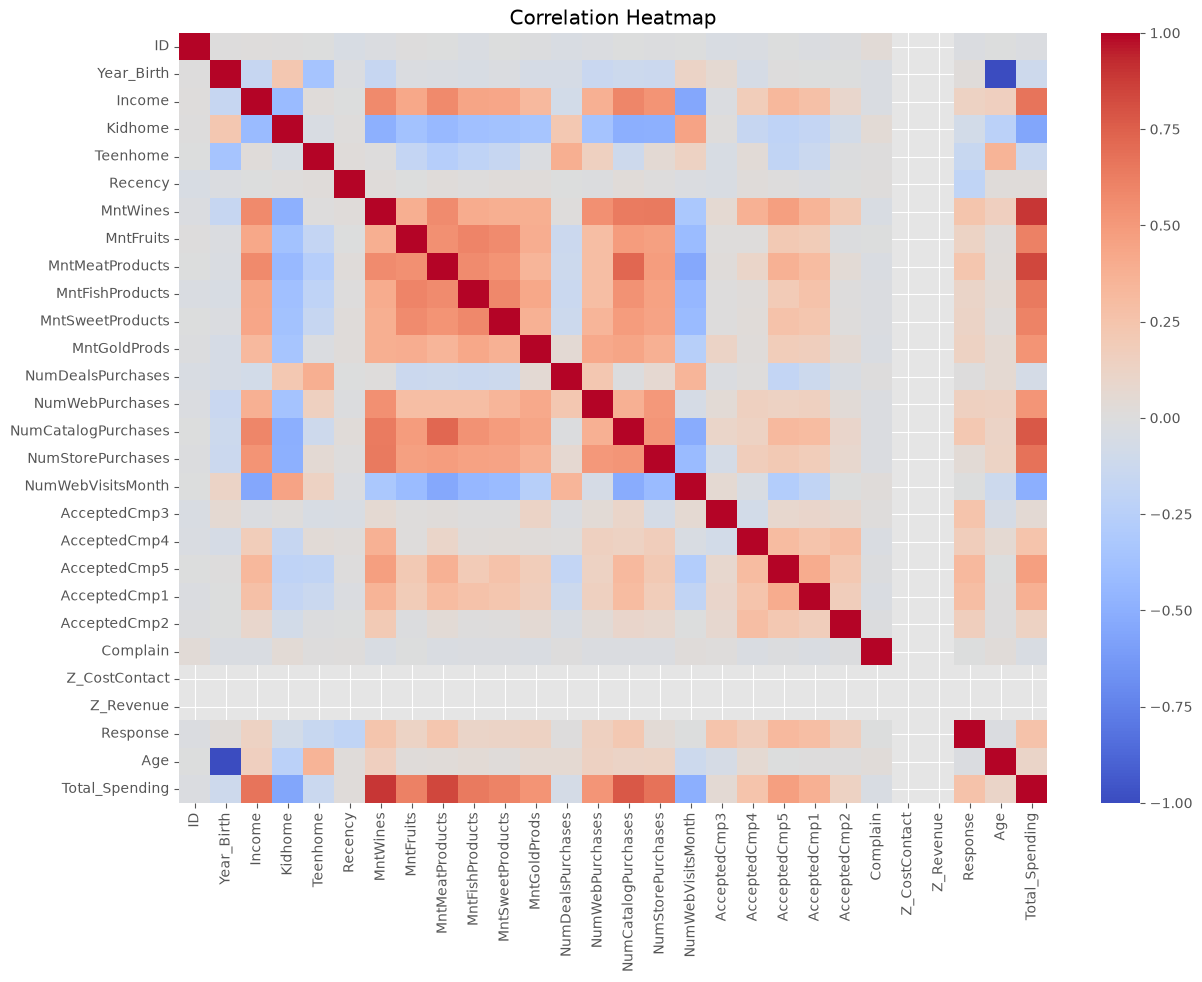

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Load Dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Dataset Overview

print("First Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

# Missing Values

print("\nMissing Values")
print(df.isnull().sum())

# Fill missing income values
df["Income"] = df["Income"].fillna(df["Income"].median())


# Duplicate Rows

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# Convert Date Column

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")

# Feature Engineering
# Customer Age
df["Age"] = 2026 - df["Year_Birth"]

# Total Spending
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Exploratory Data Analysis

# Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Income"], bins=30)
plt.title("Income Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30)
plt.title("Customer Age Distribution")
plt.show()

# Education Distribution
plt.figure(figsize=(10,5))
sns.countplot(y="Education", data=df,
              order=df["Education"].value_counts().index)
plt.title("Education Level")
plt.show()

# Marital Status
plt.figure(figsize=(10,5))
sns.countplot(y="Marital_Status", data=df,
              order=df["Marital_Status"].value_counts().index)
plt.title("Marital Status")
plt.show()

# Total Spending
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Spending"], bins=30)
plt.title("Total Customer Spending")
plt.show()

# Spending by Product Category
products = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

plt.figure(figsize=(10,5))
df[products].sum().plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.ylabel("Amount")
plt.show()

# Campaign Response
plt.figure(figsize=(5,5))
sns.countplot(x="Response", data=df)
plt.title("Marketing Campaign Response")
plt.xticks([0,1],["No","Yes"])
plt.show()

# Income vs Spending
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x="Income",
                y="Total_Spending",
                alpha=0.6)
plt.title("Income vs Total Spending")
plt.show()

# Web Visits
plt.figure(figsize=(8,5))
sns.histplot(df["NumWebVisitsMonth"], bins=15)
plt.title("Monthly Website Visits")
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

